In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import sys
sys.path.append('..')  # Add parent directory to path

import torch
import torch.nn as nn
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from src.models import DLDModule
from src.models.components import DirectionalDiffusion, DirectionalConditionalModel

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

PyTorch version: 2.8.0
CUDA available: True
Using device: cuda


## Step 1: Load or Prepare Data

First, you need to have:
1. A dataset with noisy labels
2. Precomputed embeddings (weak and strong augmentation views)

In [14]:
# Load your dataset
from src.data.surface_datamodule import SurfaceDataModule

datamodule = SurfaceDataModule(
    data_root="../data",
    data_path="surface",
    batch_size=32,
    num_workers=4,
)
datamodule.setup('fit')

# Get dataset information
num_classes = datamodule.num_classes
num_samples = len(datamodule.train_dataset)
fp_dim = 128

print(f"Dataset size: {num_samples}")
print(f"Number of classes: {num_classes}")
print(f"Embedding dimension: {fp_dim}")

# Extract real embeddings from the dataset
# Note: We'll compute these after initializing the feature encoder in the next step
# For now, we'll create placeholders that will be filled in
weak_embed = None
strong_embed = None
train_labels = None

print("\nEmbeddings will be computed in the next cells after initializing the feature encoder")

Dataset size: 5550
Number of classes: 10
Embedding dimension: 128

Embeddings will be computed in the next cells after initializing the feature encoder


## Step 2: Initialize Feature Encoder

The feature encoder extracts features from images for k-NN label correction.

In [15]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Remove final classification layer
fp_encoder = nn.Sequential(
    *list(resnet.children())[:-1],
    nn.Flatten(),
    nn.Linear(512, fp_dim),  # Project to fp_dim
)

fp_encoder = fp_encoder.to(device)
fp_encoder.eval()

print("Feature encoder initialized")

Feature encoder initialized


## Step 2.1: Extract Real Embeddings

Now that we have the feature encoder, let's extract embeddings from the actual dataset for both weak and strong augmentation views.

In [16]:
from tqdm import tqdm

def extract_embeddings_from_dataloader(dataloader, encoder, device='cuda', desc="Extracting"):
    """Extract embeddings from a dataloader."""
    embeddings_list = []
    labels_list = []
    
    encoder.eval()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc):
            images, labels = batch[:2]  # Get images and labels
            images = images.to(device)
            
            # Extract features
            emb = encoder(images)
            embeddings_list.append(emb.cpu())
            labels_list.append(labels.cpu())
    
    embeddings = torch.cat(embeddings_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    
    return embeddings, labels

# Extract embeddings for training data
print("Extracting embeddings for weak augmentation view...")
train_loader = datamodule.train_dataloader()
weak_embed, train_labels = extract_embeddings_from_dataloader(
    train_loader, fp_encoder, device, desc="Weak augmentation"
)

print(f"\nExtracted embeddings:")
print(f"  Weak embeddings shape: {weak_embed.shape}")
print(f"  Train labels shape: {train_labels.shape}")

# For strong augmentation, you would typically create a separate dataloader with stronger augmentations
# For now, we'll simulate strong embeddings with additional noise for demonstration
print("\nNote: In production, you should create a separate dataloader with strong augmentations")
print("For this demo, we'll add small perturbations to simulate strong augmentation embeddings")
strong_embed = weak_embed + torch.randn_like(weak_embed) * 0.1

print(f"  Strong embeddings shape: {strong_embed.shape}")
print("\nEmbeddings extracted successfully!")

Extracting embeddings for weak augmentation view...


Weak augmentation:   0%|          | 0/139 [00:00<?, ?it/s]

Weak augmentation: 100%|██████████| 139/139 [00:08<00:00, 15.58it/s]


Extracted embeddings:
  Weak embeddings shape: torch.Size([4440, 128])
  Train labels shape: torch.Size([4440])

Note: In production, you should create a separate dataloader with strong augmentations
For this demo, we'll add small perturbations to simulate strong augmentation embeddings
  Strong embeddings shape: torch.Size([4440, 128])

Embeddings extracted successfully!


## Step 3: Initialize Diffusion Model

In [17]:
# Initialize base conditional model
base_model = DirectionalConditionalModel(
    n_steps=1000,
    y_dim=num_classes,
    fp_dim=fp_dim,
    feature_dim=512,
    guidance=True,
    num_models=2,  # Dual model (residual + noise)
    objective='pred_res_noise',
    encoder_type='resnet18',
)

# Initialize diffusion wrapper
diffusion_model = DirectionalDiffusion(
    model=base_model,
    fp_encoder=fp_encoder,
    num_models=2,
    num_timesteps=1000,
    n_class=num_classes,
    fp_dim=fp_dim,
    device=device,
    feature_dim=512,
    encoder_type='resnet18',
    objective='pred_res_noise',
    sampling_timesteps=10,  # DDIM steps for inference
    condition=True,
    convert_to_ddim=False,
    sum_scale=1.0,
    ddim_sampling_eta=0.0,
    beta_schedule='cosine',
)

print("Diffusion model initialized")
print(f"Number of models: {diffusion_model.num_models}")
print(f"Objective: {diffusion_model.objective}")

Diffusion model initialized
Number of models: 2
Objective: pred_res_noise


## Step 4: Initialize DLD Lightning Module

In [18]:
# Initialize DLD module
model = DLDModule(
    diffusion_model=diffusion_model,
    num_classes=num_classes,
    k=30,  # Number of nearest neighbors
    warmup_epochs=2,
    learning_rate=0.001,
    use_loss_weights=True,
    to_single_label=False,
    one_view=False,
    use_cosine_similarity=True,
)

# Set precomputed embeddings
model.set_embeddings(
    weak_embed=weak_embed,
    strong_embed=strong_embed,
    train_labels=train_labels,
)

print("DLD module initialized")
print(f"k-NN neighbors: {model.k}")
print(f"Learning rate: {model.learning_rate}")

DLD module initialized
k-NN neighbors: 30
Learning rate: 0.001


## Step 5: Configure Trainer and Train

In [34]:
"""Progress callback for DLD training to show what's happening."""

from lightning.pytorch.callbacks import Callback
import time


class DLDProgressCallback(Callback):
    """Callback to show detailed progress during DLD training."""
    
    def __init__(self, log_every_n_batches: int = 10):
        super().__init__()
        self.log_every_n_batches = log_every_n_batches
        self.batch_start_time = None
        self.epoch_start_time = None
        
    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_start_time = time.time()
        print(f"\n{'='*60}")
        print(f"Starting Epoch {trainer.current_epoch}")
        print(f"{'='*60}")
        
    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        self.batch_start_time = time.time()
        if batch_idx % self.log_every_n_batches == 0:
            print(f"\nBatch {batch_idx}/{trainer.num_training_batches}")
            print(f"  Step 1/4: Loading batch and embeddings...")
            
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        if batch_idx % self.log_every_n_batches == 0:
            batch_time = time.time() - self.batch_start_time
            print(f"  ✓ Batch {batch_idx} complete in {batch_time:.2f}s")
            
            # Show losses if available
            if outputs is not None:
                loss_info = []
                if 'res_loss' in outputs:
                    loss_info.append(f"res_loss={outputs['res_loss']:.4f}")
                if 'noise_loss' in outputs:
                    loss_info.append(f"noise_loss={outputs['noise_loss']:.4f}")
                if 'loss' in outputs:
                    loss_info.append(f"loss={outputs['loss']:.4f}")
                if loss_info:
                    print(f"    Losses: {', '.join(loss_info)}")
                    
    def on_train_epoch_end(self, trainer, pl_module):
        epoch_time = time.time() - self.epoch_start_time
        print(f"\n{'='*60}")
        print(f"Epoch {trainer.current_epoch} complete in {epoch_time/60:.2f} minutes")
        print(f"{'='*60}\n")
        
    def on_validation_start(self, trainer, pl_module):
        print(f"\n{'*'*60}")
        print(f"Starting Validation after Epoch {trainer.current_epoch}")
        print(f"{'*'*60}")
        
    def on_validation_end(self, trainer, pl_module):
        print(f"{'*'*60}")
        print(f"Validation complete")
        print(f"{'*'*60}\n")

# Configure callbacks
checkpoint_callback = ModelCheckpoint(
    monitor='val/acc',
    mode='max',
    save_top_k=3,
    filename='dld-{epoch:02d}-{val_acc:.3f}',
)

early_stopping = EarlyStopping(
    monitor='val/acc',
    patience=20,
    mode='max',
)

progress_callback = DLDProgressCallback(log_every_n_batches=10)

# Initialize trainer
trainer = Trainer(
    max_epochs=100,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping],
    enable_progress_bar=True,
    log_every_n_steps=10,
)

print("Trainer configured")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Trainer configured


In [35]:
# Train the model
# Note: You need to provide actual datamodule with train/val/test loaders
trainer.fit(model, datamodule)

print("\nTraining would start here with: trainer.fit(model, datamodule)")
print("Make sure your datamodule provides batches in format:")
print("  - (weak_aug_images, strong_aug_images, labels, indices)")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃    ┃ Name             ┃ Type                 ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0  │ diffusion_model  │ DirectionalDiffusion │ 24.2 M │ eval │     0 │
│ 1  │ diffusion_loss   │ MSELoss              │      0 │ eval │     0 │
│ 2  │ train_loss_res   │ MeanMetric           │      0 │ eval │     0 │
│ 3  │ train_loss_noise │ MeanMetric           │      0 │ eval │     0 │
│ 4  │ val_acc          │ MulticlassAccuracy   │      0 │ eval │     0 │
│ 5  │ test_acc         │ MulticlassAccuracy   │      0 │ eval │     0 │
│ 6  │ val_precision    │ MulticlassPrecision  │      0 │ eval │     0 │
│ 7  │ test_precision   │ MulticlassPrecision  │      0 │ eval │     0 │
│ 8  │ val_recall       │ MulticlassRecall     │      0 │ eval │     0 │
│ 9  │ test_recall      │ MulticlassRecall     │      0 │ eval │     0 │
│ 10 │ val_f1           │ MulticlassF1Score    │      0 │ eval │     0 │
│ 11 │ test_f1          │ MulticlassF1Score    │      0 │ eval │     0 │
│ 12 │ val_acc_best     │ MaxMetric            │      0 │ eval │     0 │
│ 13 │ test_acc_best    │ MaxMetric            │      0 │ eval │     0 │
└────┴──────────────────┴──────────────────────┴────────┴──────┴───────┘

Trainable params: 24.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.2 M                                                                                               
Total estimated model params size (MB): 96                                                                         
Modules in train mode: 0                                                                                           
Modules in eval mode: 182                                                                                          
Total FLOPs: 0

/home/lukasb/miniforge3/envs/defect-detection/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lukasb/miniforge3/envs/defect-detection/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:534:
Found 183 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If
this is intentional, you can ignore this warning.


Training would start here with: trainer.fit(model, datamodule)
Make sure your datamodule provides batches in format:
  - (weak_aug_images, strong_aug_images, labels, indices)


## Step 6: Inference Example

Inference Results:
  True Label: bend
  Predicted Label: crack
  Confidence: 100.00%

Top 3 Predictions:
  1. crack: 100.00%
  2. black_stain: 0.00%
  3. bend: 0.00%


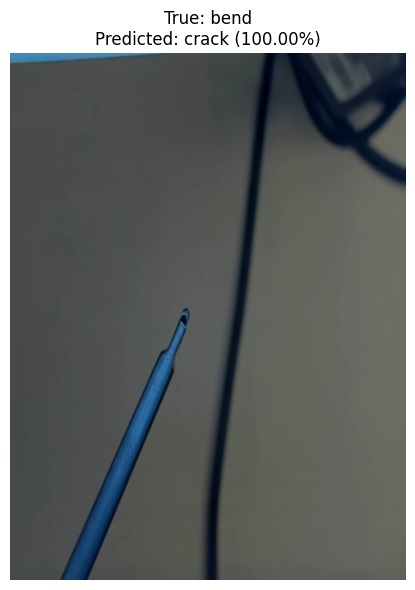

In [36]:
# Inference on real test image
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import numpy as np

# Set model to evaluation mode and ensure it's on correct device
model.to(device)
model.eval()

# Ensure fp_encoder is on the correct device
fp_encoder = fp_encoder.to(device)
fp_encoder.eval()

# Get a real test image from the dataset
test_dataset = datamodule.test_dataset
test_idx = 0  # First test image

# Get image and true label
test_image, true_label = test_dataset[test_idx]

# Prepare image for inference (add batch dimension)
test_image_batch = test_image.unsqueeze(0).to(device)

# Extract feature embedding
with torch.no_grad():
    fp_embed = fp_encoder(test_image_batch)
    
    # Run inference
    predictions = model.forward(test_image_batch, fp_embed)
    predicted_probs = torch.softmax(predictions, dim=1)
    predicted_label = torch.argmax(predictions, dim=1).item()
    confidence = predicted_probs[0, predicted_label].item()

# Get class names if available
if hasattr(datamodule, 'class_names'):
    class_names = datamodule.class_names
    true_class = class_names[true_label]
    pred_class = class_names[predicted_label]
else:
    true_class = f"Class {true_label}"
    pred_class = f"Class {predicted_label}"

# Display results
print(f"Inference Results:")
print(f"  True Label: {true_class}")
print(f"  Predicted Label: {pred_class}")
print(f"  Confidence: {confidence:.2%}")
print(f"\nTop 3 Predictions:")
top3_probs, top3_indices = torch.topk(predicted_probs[0], 3)
for i, (prob, idx) in enumerate(zip(top3_probs, top3_indices)):
    class_name = class_names[idx] if hasattr(datamodule, 'class_names') else f"Class {idx}"
    print(f"  {i+1}. {class_name}: {prob:.2%}")

# Visualize the image
plt.figure(figsize=(8, 6))
# Denormalize image for display
img_display = test_image.permute(1, 2, 0).cpu().numpy()
# If normalized, denormalize (assuming ImageNet normalization)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

plt.imshow(img_display)
plt.title(f"True: {true_class}\nPredicted: {pred_class} ({confidence:.2%})")
plt.axis('off')
plt.tight_layout()
plt.show()

## Batch Inference on Multiple Test Images

You can also run inference on multiple images at once:

In [37]:
# Batch inference on test dataloader
model.eval()

# Get test dataloader
test_loader = datamodule.test_dataloader()

# Run inference on first batch
with torch.no_grad():
    for batch in test_loader:
        images, labels = batch[:2]
        images = images.to(device)
        labels = labels.to(device)
        
        # Extract embeddings
        fp_embeds = fp_encoder(images)
        
        # Get predictions
        predictions = model.forward(images, fp_embeds)
        predicted_labels = torch.argmax(predictions, dim=1)
        
        # Calculate accuracy for this batch
        correct = (predicted_labels == labels).sum().item()
        accuracy = correct / len(labels)
        
        print(f"Batch inference complete:")
        print(f"  Batch size: {len(labels)}")
        print(f"  Accuracy: {accuracy:.2%} ({correct}/{len(labels)} correct)")
        print(f"  Predictions: {predicted_labels.cpu().numpy()}")
        print(f"  True labels: {labels.cpu().numpy()}")
        
        break  # Only process first batch for demo

Batch inference complete:
  Batch size: 32
  Accuracy: 18.75% (6/32 correct)
  Predictions: [5 7 3 7 1 6 6 3 7 6 1 4 3 6 6 5 3 7 3 5 5 0 6 0 7 0 0 0 0 4 6 5]
  True labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Step 7: Save and Load Model

In [ ]:
# Save model
# trainer.save_checkpoint("dld_model.ckpt")

# Load model
# loaded_model = DLDModule.load_from_checkpoint(
#     "dld_model.ckpt",
#     diffusion_model=diffusion_model,
# )

print("Model can be saved with: trainer.save_checkpoint()")
print("And loaded with: DLDModule.load_from_checkpoint()")

## Summary

This notebook demonstrated:

1. **Data Preparation**: Loading dataset and precomputed embeddings
2. **Model Initialization**: Creating diffusion model and DLD module
3. **Training**: Configuring trainer with callbacks
4. **Inference**: Making predictions with trained model
5. **Persistence**: Saving and loading models

## Next Steps

- Precompute embeddings for your dataset using `scripts/precompute_embeddings.py`
- Adjust hyperparameters (k, learning rate, warmup epochs)
- Experiment with different encoder architectures
- Try single vs dual model training
- Tune augmentation strategies